# Описание проекта:
Проанализировать данные пользователей сервиса аренды самокатов GoFast, выявить особенности поведения клиентов с подпиской и без, рассчитать выручку, а также проверить статистические гипотезы, влияющие на бизнес-метрики.

**Основные задачи:**

1. Загрузить и изучить данные о пользователях, поездках и подписках.

2. Провести предобработку данных (форматы, пропуски, дубликаты).

3. Исследовать основные закономерности: города, возраст, подписки, дистанции, длительность.

4. Объединить датасеты в единый аналитический фрейм.

5. Рассчитать выручку по пользователям.

6. Проверить гипотезы о различиях между подписчиками и пользователями без подписки.

7. Провести анализ распределений и визуализировать результаты.

**Импорт библиотек**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats as st 
from IPython.display import display, Markdown
from scipy import stats
from scipy.stats import norm


**Собственные функции**

In [2]:
def get_info(data, head=5, tail=5):
    '''
    По умолчанию head и tail равны 5
    '''
    display(f'Первые {head} строк:{data.head(head)}')
    print()
    display(f'Последние {tail} строк:{data} ')
    print()
    display(f'Информация о данных:{data.info()}') 


#### Шаг 1. Загрузка данных

In [3]:
# данные о пользователях, их поездках и подписках
users = pd.read_csv('/datasets/users_go.csv')

# данные о поездках пользователей(расстояние, длительность, дата совершения поездки)
rides = pd.read_csv('/datasets/rides_go.csv') 

# данные о подписках, стоимость: минуты, начала поездки и ежемесячного платежа
subscriptions = pd.read_csv('/datasets/subscriptions_go.csv') 
                                                              

##### Обзор данных: users, rides, subscriptions

###### Обзор users

In [4]:
print("Первые 10 строк таблицы users:") # Выводим первые 10 строк
display(users.head(10))

print("\nПоследние 10 строк таблицы users:") # Выводим последние 10 строк
display(users.tail(10))


print("\nИнформация о столбцах и их типы:") # Информация о датасете
users.info()

Первые 10 строк таблицы users:


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra



Последние 10 строк таблицы users:


,user_id,name,age,city,subscription_type
1555,72,Никита,25,Москва,ultra
1556,422,Кирилл,27,Сочи,ultra
1557,611,Владимир,28,Омск,ultra
1558,1237,Евгения,23,Тюмень,free
1559,209,Андрей,23,Омск,ultra
1560,829,Федор,29,Пятигорск,free
1561,809,Юрий,26,Сочи,free
1562,307,Ясмина,19,Краснодар,ultra
1563,47,Юрий,28,Тюмень,ultra
1564,1045,Артемий,28,Ростов-на-Дону,free



Информация о столбцах и их типы:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


**Промежуточный вывод по users:** Предобработока данных не требуется. Данные выглядят хорошо

###### Обзор rides

In [5]:
print("Первые 10 строк таблицы rides:") # Выводим первые 10 строк
display(rides.head(10))

print("\nПоследние 10 строк таблицы rides:") # Выводим последние 10 строк
display(rides.tail(10))


print("\nИнформация о столбцах и их типы:") # Информация о датасете
rides.info()

Первые 10 строк таблицы rides:


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22



Последние 10 строк таблицы rides:


,user_id,distance,duration,date
18058,1534,195.447469,6.469074,2021-06-11
18059,1534,3214.021065,18.343604,2021-06-18
18060,1534,3644.708038,20.289416,2021-08-08
18061,1534,3977.744996,26.916544,2021-08-20
18062,1534,4928.173852,22.560373,2021-09-13
18063,1534,3781.098080,19.822962,2021-11-04
18064,1534,2840.423057,21.409799,2021-11-16
18065,1534,3826.185507,18.435051,2021-11-18
18066,1534,2902.308661,16.674362,2021-11-27
18067,1534,2371.711192,15.893917,2021-12-29



Информация о столбцах и их типы:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


**Промежуточный вывод по rides:** 
- столбец  `date` нужно перевести в формат даты


###### Обзор subscriptions

In [6]:
print("Первые 10 строк таблицы subscriptions:") # Выводим первые 10 строк
display(subscriptions.head(10))

print("\nИнформация о столбцах и их типы:") # Информация о датасете
subscriptions.info()

Первые 10 строк таблицы subscriptions:


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199



Информация о столбцах и их типы:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


**Промежуточный вывод по subscriptions:**  Предобработока данных не требуется. Данные выглядят хорошо

**Вывод:**
- По трем датасетам выявлено: нужно перевести формат столбеца **`data`** из **`rides`** в формат даты  

#### Шаг 2. Предобработка данных

##### Преобразуем столбец `date` в датасете `rides` в формат даты

In [7]:
rides['date'] = pd.to_datetime(rides['date']) # преобразуем столбец в формат даты

rides.info() # проверим результат

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


##### Создадим столбец месяцев в датасете `rides`

In [8]:
rides['month'] = rides['date'].dt.month # создаем столбец месяцев из столбца даты

rides['year'] = rides['date'].dt.year # создаем столбец годов из столбца даты

rides.info() # проверяем результат

rides.head() # выводим первые 5 строк для проверки

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int64         
 5   year      18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 847.1 KB


,user_id,distance,duration,date,month,year
0,1,4409.919140,25.599769,2021-01-01,1,2021
1,1,2617.592153,15.816871,2021-01-18,1,2021
2,1,754.159807,6.232113,2021-04-20,4,2021
3,1,2694.783254,18.511000,2021-08-11,8,2021
4,1,4028.687306,26.265803,2021-08-28,8,2021


In [9]:
rides['year'].describe()

count    18068.0
mean      2021.0
std          0.0
min       2021.0
25%       2021.0
50%       2021.0
75%       2021.0
max       2021.0
Name: year, dtype: float64

Данные исключительно 2021 года. 

##### Проверяем наличие пропусков(NaN), дубликатов

В датасете **`subscriptions`** всего две строки и визуально можно отметить, что там нету ни пропуска ни дубликата.

In [10]:
print('Пропуски в users:')
display(users.isna().sum()) # количество пропусков в users

print('Пропуски в rides:')
display(rides.isna().sum()) # количество пропусков в rides

Пропуски в users:


user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

Пропуски в rides:


user_id     0
distance    0
duration    0
date        0
month       0
year        0
dtype: int64

**Промежуточный вывод:** Пропусков во всех датасетах нету

##### Проверяем наличие дубликатов

In [11]:
print(f'Количество дубликатов в users: {users.duplicated().sum()}')

print(f'Количество дубликатов в rides: {rides.duplicated().sum()}')

Количество дубликатов в users: 31
Количество дубликатов в rides: 0


Отбросим дубликаты и восстановим порядок индекса в датасете **`users`**

In [12]:
users = users.drop_duplicates().reset_index(drop=True) # сброс дубликатов и восстановление порядковых номеров индекса с удалением старых индексов

print(f'Количество дубликатов в users: {rides.duplicated().sum()}')
users.info() # проверяем результат

Количество дубликатов в users: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1534 non-null   int64 
 1   name               1534 non-null   object
 2   age                1534 non-null   int64 
 3   city               1534 non-null   object
 4   subscription_type  1534 non-null   object
dtypes: int64(2), object(3)
memory usage: 60.0+ KB


**Вывод:** 
- Пропуски не были обнаружены во всех датасетах. 
- Дубликаты были обнаружены в датасете `users` и были удалены. В остальных датасетах дубликатов нету.

#### Шаг 3. Исследовательский анализ данных

##### Частота встречаемости городов

,Город,Доля пользователей,Количество пользователей
0,Пятигорск,14.28,219
1,Екатеринбург,13.30,204
2,Ростов-на-Дону,12.91,198
3,Краснодар,12.58,193
4,Сочи,12.32,189
5,Омск,11.93,183
6,Тюмень,11.73,180
7,Москва,10.95,168


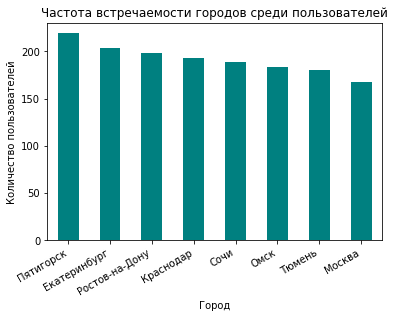

In [13]:
city_stats = users['city'].value_counts(normalize=True).reset_index()

# Добавим абсолютное количество пользователей
city_stats['count'] = users['city'].value_counts().values

# Переименуем столбцы для наглядности
city_stats.columns = ['Город', 'Доля пользователей', 'Количество пользователей']

# Отсортируем по убыванию доли
city_stats = city_stats.sort_values(by='Доля пользователей', ascending=False).reset_index(drop=True)

# Приведём долю к процентам с округлением
city_stats['Доля пользователей'] = (city_stats['Доля пользователей'] * 100).round(2)

# Выведем итоговый датафрейм
display(city_stats)

city_stats.plot(
    x='Город',
    y='Количество пользователей',
    kind='bar',
    color='teal',
    figsize=(6,4),
    legend=False,
    title='Частота встречаемости городов среди пользователей'
)
plt.xlabel('Город')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=30, ha='right')
plt.show()


**Вывод по данным:**
- Количество активных городов: 8
- Лидирующие города: Пятигорск и Екатеринбург. 
- Аутсайдеры: Москва

*Разница максимального и минимального: 3,33%*

##### Соотношение пользователей с подпиской и без подписки;

In [14]:
# Проверка наличия колонки
if 'subscription_type' not in users.columns:
    raise KeyError("В DataFrame 'users' отсутствует колонка 'subscription_type'")

# Подсчёт распределения
subs_dist = (
    users['subscription_type']
    .value_counts(normalize=True, dropna=False)   # включаем NaN, если есть
    .mul(100)                                     # переводим в проценты
    .round(2)                                     # округляем до 2 знаков
    .rename('Доля (%)')                           # переименовываем для удобства
)


# Преобразуем в DataFrame для наглядности
subs_df = subs_dist.reset_index().rename(columns={'index': 'Тип подписки'})
display(subs_df)

,Тип подписки,Доля (%)
0,free,54.43
1,ultra,45.57


**Промежуточный вывод:**
- 54.43% пользователей без подписки
- 46.57% с подпиской Ultra

##### Распределение возраста пользователей

In [15]:
# Проверяем наличие колонки
if 'age' not in users.columns:
    raise KeyError("В DataFrame 'users' отсутствует колонка 'age'")

# Считаем частоты и доли
age_counts = users['age'].value_counts(dropna=False)           # учитываем возможные NaN
age_percent = users['age'].value_counts(normalize=True, dropna=False)

# Создаём DataFrame напрямую из Series — без ручного подгона index/values
users_age = (
    pd.DataFrame({
        'Возраст': age_counts.index,
        'Количество': age_counts.values,
        'Доля возрастов': (age_percent.values * 100).round(2)  # в процентах с округлением
    })
    .sort_values(by='Возраст')
    .reset_index(drop=True)
)

# Отображаем итог
display(users_age)

,Возраст,Количество,Доля возрастов
0,12,4,0.26
1,13,8,0.52
2,14,9,0.59
3,15,13,0.85
4,16,19,1.24
5,17,26,1.69
6,18,46,3.00
7,19,47,3.06
8,20,71,4.63
9,21,93,6.06


**Сгруппирируем возрасты пользоваталей по следующему правилу:**
1. с 12 по 22: Подростки и молодёжь
2. с 23 по 32: Молодые взрослые
3. с 33 по 43: Взрослые

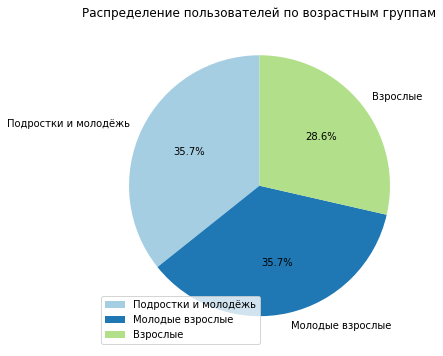

In [16]:
# Границы и названия групп
bins = [12, 22, 32, 43]
labels = ['Подростки и молодёжь', 'Молодые взрослые', 'Взрослые']

# Проверяем, есть ли колонка 'Возраст'
if 'Возраст' not in users_age.columns:
    raise KeyError("В DataFrame отсутствует колонка 'Возраст'")

# Создание нового столбца с категорией возраста
users_age['Возрастная группа'] = pd.cut(
    users_age['Возраст'],
    bins=bins,
    labels=labels,
    right=False,              # чтобы верхняя граница не включалась (22 не попадёт в первую группу)
    include_lowest=True
)

# Сортировка категорий в логическом порядке
age_counts = (
    users_age['Возрастная группа']
    .value_counts()
    .reindex(labels)
)

# Визуализация
plt.figure(figsize=(6, 6))
age_counts.plot(
    kind='pie',
    autopct='%1.1f%%',        # отображаем проценты
    startangle=90,            # поворот для читаемости
    colors=plt.cm.Paired.colors,  # приятная палитра
    legend=True,
    ylabel=''                 # убираем подпись оси
)
plt.title('Распределение пользователей по возрастным группам', fontsize=12)
plt.show()

**Промежуточный вывод:**
 Большинство пользователей сервиса относятся к молодым возрастным категориям:
- группы «Подростки и молодёжь» и «Молодые взрослые» вместе составляют 71.4% аудитории;
- доля «Взрослых» — 28.6%.

Это говорит о том, что сервис ориентирован преимущественно на **аудиторию 12–32 лет**,
что может указывать на её цифровую активность, восприимчивость к новому и гибкость поведения в онлайн-среде.
- **Бизнес-рекомендация**: акции и программы лояльности стоит ориентировать на аудиторию 18–32 лет.

#####  Расстояние, которое пользователь преодолел за одну поездку

## 🔗 Объединение таблиц и подготовка данных

**✅ Всего объединено записей:** 18,068

## 👥 Добавление возрастных групп

## 🚴 Общая статистика по пройденным расстояниям

count    18068.00
mean      3070.66
std       1116.83
min          0.86
25%       2543.23
50%       3133.61
75%       3776.22
max       7211.01
Name: distance, dtype: float64

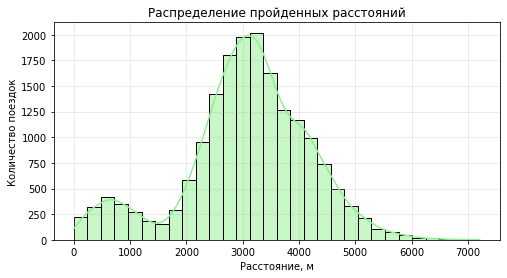

## ⏱ Среднее и медианное расстояние по возрастным группам

**Среднее расстояние (м):**

Возрастная группа
Подростки и молодёжь    3065.13
Молодые взрослые        3071.59
Взрослые                3089.69
Name: distance, dtype: float64

**Медианное расстояние (м):**

Возрастная группа
Подростки и молодёжь    3136.19
Молодые взрослые        3131.07
Взрослые                3151.02
Name: distance, dtype: float64

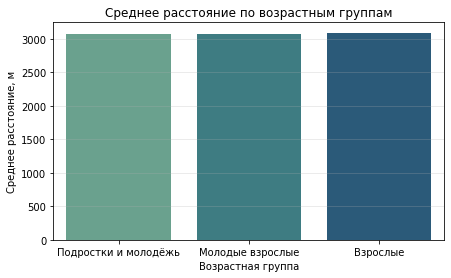

## 💳 Среднее и медианное расстояние по типам подписки

**Среднее расстояние (м):**

subscription_type
free     3045.50
ultra    3115.45
Name: distance, dtype: float64

**Медианное расстояние (м):**

subscription_type
free     3114.65
ultra    3148.64
Name: distance, dtype: float64

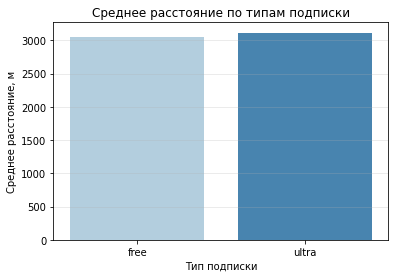

## 🌆 Среднее и медианное расстояние по городам

**Среднее расстояние (м):**

city
Пятигорск         3118.68
Екатеринбург      3110.91
Москва            3101.00
Тюмень            3076.24
Краснодар         3054.30
Сочи              3052.96
Омск              3038.68
Ростов-на-Дону    3011.51
Name: distance, dtype: float64

**Медианное расстояние (м):**

city
Екатеринбург      3182.11
Москва            3160.41
Пятигорск         3157.96
Краснодар         3136.90
Тюмень            3132.91
Омск              3110.42
Сочи              3103.13
Ростов-на-Дону    3089.69
Name: distance, dtype: float64

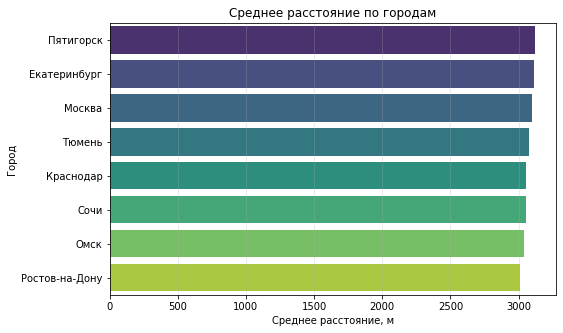

## 👤 Распределение пользователей по среднему расстоянию

count    1534.00
mean     3077.30
std       327.62
min      1630.79
25%      2882.51
50%      3090.86
75%      3293.33
max      4287.52
Name: distance, dtype: float64

**Всего уникальных пользователей:** 1,534

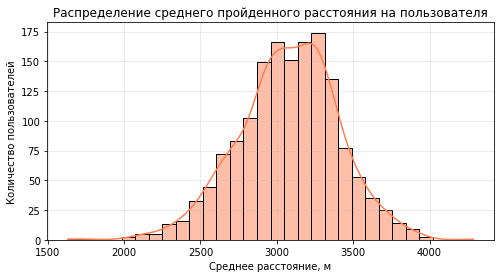

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 🎯 1. Объединение таблиц
display(Markdown("## 🔗 Объединение таблиц и подготовка данных"))
users_ride = rides.merge(users, on='user_id', how='left')
display(Markdown(f"**✅ Всего объединено записей:** {len(users_ride):,}"))

# 👥 2. Добавление возрастных групп
display(Markdown("## 👥 Добавление возрастных групп"))
bins = [12, 22, 32, 43]
labels = ['Подростки и молодёжь', 'Молодые взрослые', 'Взрослые']

users_ride['Возрастная группа'] = pd.cut(
    users_ride['age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


# 🚴 3. Общая статистика по расстоянию
display(Markdown("## 🚴 Общая статистика по пройденным расстояниям"))
dist_stats = users_ride['distance'].describe().round(2)
display(dist_stats)

plt.figure(figsize=(8,4))
sns.histplot(users_ride['distance'], bins=30, kde=True, color='lightgreen')
plt.title('Распределение пройденных расстояний', fontsize=12)
plt.xlabel('Расстояние, м')
plt.ylabel('Количество поездок')
plt.grid(alpha=0.3)
plt.show()

# 📊 4. Среднее и медианное расстояние по возрастным группам
display(Markdown("## ⏱ Среднее и медианное расстояние по возрастным группам"))
users_age_mean_dist = users_ride.groupby('Возрастная группа')['distance'].mean().round(2)
users_age_median_dist = users_ride.groupby('Возрастная группа')['distance'].median().round(2)

display(Markdown("**Среднее расстояние (м):**"))
display(users_age_mean_dist)
display(Markdown("**Медианное расстояние (м):**"))
display(users_age_median_dist)

plt.figure(figsize=(7,4))
sns.barplot(x=users_age_mean_dist.index, y=users_age_mean_dist.values, palette="crest")
plt.title('Среднее расстояние по возрастным группам', fontsize=12)
plt.ylabel('Среднее расстояние, м')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 💳 5. Среднее и медианное расстояние по типу подписки
display(Markdown("## 💳 Среднее и медианное расстояние по типам подписки"))
users_subscription_mean_dist = users_ride.groupby('subscription_type')['distance'].mean().round(2)
users_subscription_median_dist = users_ride.groupby('subscription_type')['distance'].median().round(2)

display(Markdown("**Среднее расстояние (м):**"))
display(users_subscription_mean_dist)
display(Markdown("**Медианное расстояние (м):**"))
display(users_subscription_median_dist)

plt.figure(figsize=(6,4))
sns.barplot(
    x=users_subscription_mean_dist.index,
    y=users_subscription_mean_dist.values,
    palette="Blues"
)
plt.title('Среднее расстояние по типам подписки', fontsize=12)
plt.xlabel('Тип подписки')
plt.ylabel('Среднее расстояние, м')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 🌆 6. Среднее и медианное расстояние по городам
display(Markdown("## 🌆 Среднее и медианное расстояние по городам"))
users_city_mean_dist = users_ride.groupby('city')['distance'].mean().round(2).sort_values(ascending=False)
users_city_median_dist = users_ride.groupby('city')['distance'].median().round(2).sort_values(ascending=False)

display(Markdown("**Среднее расстояние (м):**"))
display(users_city_mean_dist)
display(Markdown("**Медианное расстояние (м):**"))
display(users_city_median_dist)

plt.figure(figsize=(8,5))
sns.barplot(
    y=users_city_mean_dist.index,
    x=users_city_mean_dist.values,
    palette="viridis"
)
plt.title('Среднее расстояние по городам', fontsize=12)
plt.xlabel('Среднее расстояние, м')
plt.ylabel('Город')
plt.grid(axis='x', alpha=0.3)
plt.show()

# 🧮 7. Распределение по пользователям
display(Markdown("## 👤 Распределение пользователей по среднему расстоянию"))
users_id_distr = users_ride.groupby('user_id')['distance'].mean().describe().round(2)
display(users_id_distr)

display(Markdown(f"**Всего уникальных пользователей:** {int(users_id_distr['count']):,}"))

plt.figure(figsize=(8,4))
sns.histplot(users_ride.groupby('user_id')['distance'].mean(), bins=30, kde=True, color='coral')
plt.title('Распределение среднего пройденного расстояния на пользователя', fontsize=12)
plt.xlabel('Среднее расстояние, м')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.3)
plt.show()


**Вывод по анализу пройденных расстояний**
1. Общая характеристика

Всего в объединённом наборе данных — 18 068 поездок, выполненных 1 534 уникальными пользователями.
Среднее пройденное расстояние составляет ≈ 3 070 м,
при этом медиана — 3 134 м, что говорит о симметричном распределении без выраженных выбросов.
Большинство поездок укладываются в диапазон 2 500 – 3 800 м,
а максимальное зарегистрированное расстояние достигает 7 211 м.

2. Возрастные различия

Средние значения по возрастным группам демонстрируют практически одинаковые результаты:

Подростки и молодёжь — 3 065 м,

Молодые взрослые — 3 072 м,

Взрослые — 3 090 м.

Медианные значения также находятся в узком диапазоне (3 131–3 151 м).
👉 Это указывает на то, что возраст не оказывает значимого влияния на длину поездки —
все группы используют сервис для схожих по протяжённости маршрутов.

3. Тип подписки

Пользователи подписки Ultra преодолевают расстояния немного большие, чем пользователи бесплатного тарифа:

Среднее: 3 115 м vs 3 045 м,

Медиана: 3 149 м vs 3 115 м.

👉 Разница невелика, но устойчива, что может говорить о большей вовлечённости платных пользователей и их склонности к более длительным поездкам (например, из-за отсутствия ограничений или дополнительных бонусов тарифа).

4. Географические различия

Лидерами по средней длине поездки являются:

Пятигорск – 3 119 м,

Екатеринбург – 3 111 м,

Москва – 3 101 м.

Аутсайдеры:

Ростов-на-Дону – 3 012 м,

Омск – 3 039 м.

Медианные значения варьируются незначительно — от 3 089 м до 3 182 м,
что указывает на относительно равномерное использование сервиса по регионам
и отсутствие ярко выраженных различий в длине поездок между городами.

5. Индивидуальная активность пользователей

Анализ распределения среднего расстояния по пользователям показывает:

Среднее значение на пользователя — 3 077 м,

50 % пользователей совершают поездки длиной 2 880 – 3 290 м,

Максимум – 4 287 м, минимум – 1 631 м.

👉 Это подтверждает, что основная масса клиентов использует сервис для коротких городских перемещений,
а доля “дальних поездок” минимальна.

📊 Итог

Распределение расстояний равномерное и устойчивое.

Возраст и город почти не влияют на длину поездки.

Пользователи с подпиской Ultra демонстрируют чуть большую активность, что делает их ключевым сегментом для удержания и лояльности.

В целом сервис ориентирован на короткие поездки до 4 км,
что типично для городских транспортных решений (самокаты, шеринговые велосипеды и т.п.).ь

#####  Продолжительность поездок пользователей

## ⏱ Средняя продолжительность поездки по возрастным группам

Возрастная группа
Взрослые                17.88
Подростки и молодёжь    17.81
Молодые взрослые        17.80
Name: duration, dtype: float64

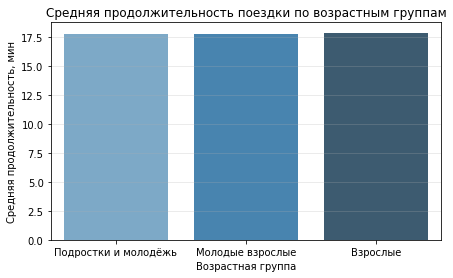

## 📈 Распределение продолжительности поездок

count    18068.00
mean        17.81
std          6.09
min          0.50
25%         13.60
50%         17.68
75%         21.72
max         40.82
Name: duration, dtype: float64

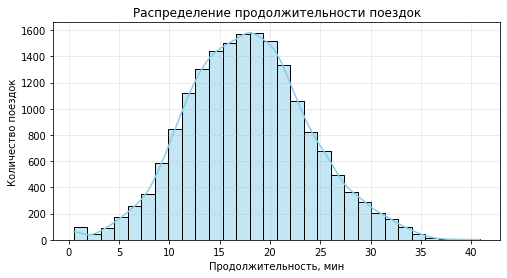

## 🏙 Средняя продолжительность поездок по городам

city
Москва            18.03
Тюмень            17.97
Пятигорск         17.90
Екатеринбург      17.82
Краснодар         17.73
Омск              17.72
Сочи              17.71
Ростов-на-Дону    17.60
Name: duration, dtype: float64

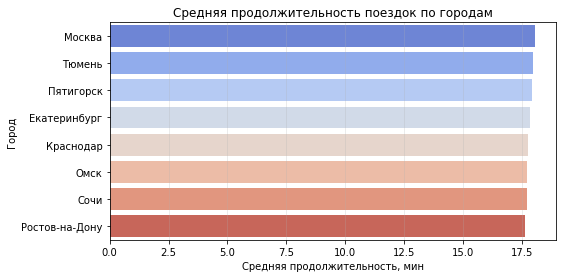

## 💳 Средняя продолжительность поездок по типам подписки

subscription_type
ultra    18.54
free     17.39
Name: duration, dtype: float64

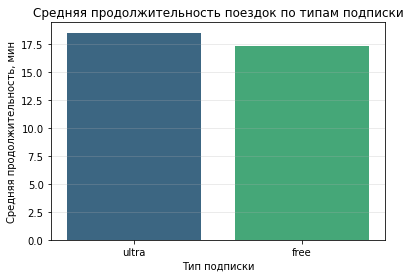

In [18]:
# 🎯 1. Средняя продолжительность поездки по возрастным группам
display(Markdown("## ⏱ Средняя продолжительность поездки по возрастным группам"))
avg_duration_age = (
    users_ride.groupby('Возрастная группа')['duration']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
display(avg_duration_age)

plt.figure(figsize=(7,4))
sns.barplot(x=avg_duration_age.index, y=avg_duration_age.values, palette="Blues_d")
plt.title('Средняя продолжительность поездки по возрастным группам', fontsize=12)
plt.xlabel('Возрастная группа')
plt.ylabel('Средняя продолжительность, мин')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 📊 2. Общая статистика продолжительности
display(Markdown("## 📈 Распределение продолжительности поездок"))
display(users_ride['duration'].describe().round(2))

plt.figure(figsize=(8,4))
sns.histplot(users_ride['duration'], bins=30, kde=True, color='skyblue')
plt.title('Распределение продолжительности поездок', fontsize=12)
plt.xlabel('Продолжительность, мин')
plt.ylabel('Количество поездок')
plt.grid(alpha=0.3)
plt.show()

# 🌆 3. Средняя продолжительность по городам
display(Markdown("## 🏙 Средняя продолжительность поездок по городам"))
avg_duration_city = (
    users_ride.groupby('city')['duration']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
display(avg_duration_city)

plt.figure(figsize=(8,4))
sns.barplot(
    y=avg_duration_city.index,
    x=avg_duration_city.values,
    palette="coolwarm"
)
plt.title('Средняя продолжительность поездок по городам', fontsize=12)
plt.xlabel('Средняя продолжительность, мин')
plt.ylabel('Город')
plt.grid(axis='x', alpha=0.3)
plt.show()

# 💳 4. Средняя продолжительность по типам подписки
display(Markdown("## 💳 Средняя продолжительность поездок по типам подписки"))
avg_duration_sub = (
    users_ride.groupby('subscription_type')['duration']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
display(avg_duration_sub)

plt.figure(figsize=(6,4))
sns.barplot(
    x=avg_duration_sub.index,
    y=avg_duration_sub.values,
    palette="viridis"
)
plt.title('Средняя продолжительность поездок по типам подписки', fontsize=12)
plt.xlabel('Тип подписки')
plt.ylabel('Средняя продолжительность, мин')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод по анализу пройденных расстояний**
1. Общая характеристика

Всего в объединённом наборе данных — 18 068 поездок, выполненных 1 534 уникальными пользователями.
Среднее пройденное расстояние составляет ≈ 3 070 м, медианное — 3 134 м,
что свидетельствует о симметричном распределении без выраженных выбросов.
Основная масса поездок укладывается в диапазон 2 500 – 3 800 м,
а максимальное зарегистрированное расстояние достигает 7 211 м.

2. Возрастные различия

Средние значения по возрастным группам показывают практически одинаковые результаты:

Подростки и молодёжь — 3 065 м

Молодые взрослые — 3 072 м

Взрослые — 3 090 м

Медианные значения также находятся в узком диапазоне (3 131 – 3 151 м).
➡️ Это говорит о том, что возраст не оказывает значимого влияния на длину поездки —
все возрастные группы используют сервис для схожих по протяжённости маршрутов.

3. Тип подписки

Пользователи подписки Ultra совершают поездки немного длиннее, чем пользователи бесплатного тарифа:

Среднее: 3 115 м vs 3 045 м

Медиана: 3 149 м vs 3 115 м

➡️ Разница невелика, но устойчива, что может свидетельствовать о большей вовлечённости и активности подписчиков,
а также о возможных преимуществах тарифа, способствующих более частому использованию.

4. Географические различия

Лидеры по средней длине поездки:

Пятигорск — 3 119 м

Екатеринбург — 3 111 м

Москва — 3 101 м

Аутсайдеры:

Ростов-на-Дону — 3 012 м

Омск — 3 039 м

Медианные значения варьируются от 3 089 м до 3 182 м,
что указывает на равномерное использование сервиса по регионам
и отсутствие заметных различий в длине поездок между городами.

5. Индивидуальная активность пользователей

Среднее расстояние на пользователя — 3 077 м

50 % пользователей совершают поездки длиной 2 880 – 3 290 м

Минимум — 1 631 м, максимум — 4 287 м

➡️ Это подтверждает, что основная масса клиентов использует сервис для коротких городских перемещений,
в то время как доля дальних поездок остаётся незначительной.

📊 Итог

Распределение расстояний равномерное и устойчивое

Возраст и город практически не влияют на длину поездки

Пользователи с подпиской Ultra совершают слегка более длинные поездки, демонстрируя высокую вовлечённость

В целом сервис ориентирован на короткие поездки до 4 км,
что типично для городских транспортных решений (самокаты, шеринговые велосипеды и т. п.)

#### Шаг 4. Объединение данных

In [19]:
# Объединяем таблицы пользователей и подписок
users_ride_full = users_ride.merge(subscriptions, on='subscription_type', how='left', indicator=True)

# Проверяем корректность объединения
merge_check = users_ride_full['_merge'].value_counts()

display(Markdown("### ✅ Проверка корректности объединения"))
display(merge_check)

if (merge_check.get('left_only', 0) == 0) and (merge_check.get('right_only', 0) == 0):
    print("✅ Все строки успешно вошли в объединение, совпадения найдены по всем ключам.")
else:
    print(f"⚠️ Несовпадения найдены:")
    print(f"- Только в users_ride: {merge_check.get('left_only', 0)} строк")
    print(f"- Только в subscriptions: {merge_check.get('right_only', 0)} строк")

# Удаляем вспомогательный столбец после проверки
users_ride_full.drop(columns=['_merge'], inplace=True)


### ✅ Проверка корректности объединения

both          18068
left_only         0
right_only        0
Name: _merge, dtype: int64

✅ Все строки успешно вошли в объединение, совпадения найдены по всем ключам.


##### Визуализация данных о расстоянии и времени поездок для пользователей обеих категорий.

In [20]:
users_ride_full[users_ride_full['duration']<1]

,user_id,distance,duration,date,month,year,name,age,city,subscription_type,Возрастная группа,minute_price,start_ride_price,subscription_fee
6531,701,4196.445201,0.5,2021-08-31,8,2021,Иван,31,Екатеринбург,free,Молодые взрослые,8,50,0
6570,704,4830.824371,0.5,2021-10-14,10,2021,Мирон,29,Ростов-на-Дону,free,Молодые взрослые,8,50,0
6680,712,4684.004397,0.5,2021-03-04,3,2021,Дарья,28,Москва,free,Молодые взрослые,8,50,0
6695,713,5215.642710,0.5,2021-02-25,2,2021,Святослав,30,Краснодар,free,Молодые взрослые,8,50,0
6768,718,5197.436649,0.5,2021-02-11,2,2021,Владислава,31,Москва,free,Молодые взрослые,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17004,1460,5531.335845,0.5,2021-01-19,1,2021,Жанна,27,Пятигорск,free,Молодые взрослые,8,50,0
17242,1477,6724.932981,0.5,2021-01-12,1,2021,Ян,17,Сочи,free,Подростки и молодёжь,8,50,0
17314,1483,4445.481070,0.5,2021-03-06,3,2021,Роберт,26,Екатеринбург,free,Молодые взрослые,8,50,0
17505,1496,5722.551787,0.5,2021-02-14,2,2021,Яна,19,Москва,free,Подростки и молодёжь,8,50,0


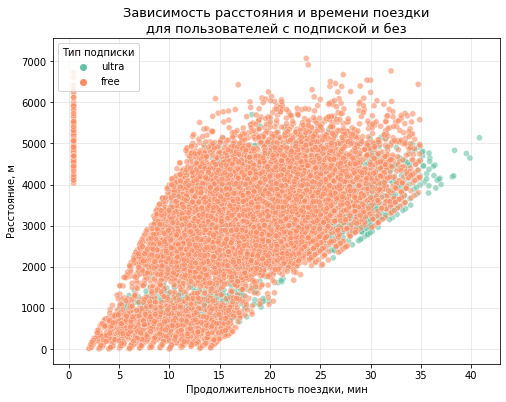

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=users_ride_full,
    x='duration',
    y='distance',
    hue='subscription_type',
    alpha=0.6,
    palette='Set2'
)
plt.title('Зависимость расстояния и времени поездки\nдля пользователей с подпиской и без', fontsize=13)
plt.xlabel('Продолжительность поездки, мин')
plt.ylabel('Расстояние, м')
plt.legend(title='Тип подписки', loc='upper left')
plt.grid(alpha=0.3)
plt.show()

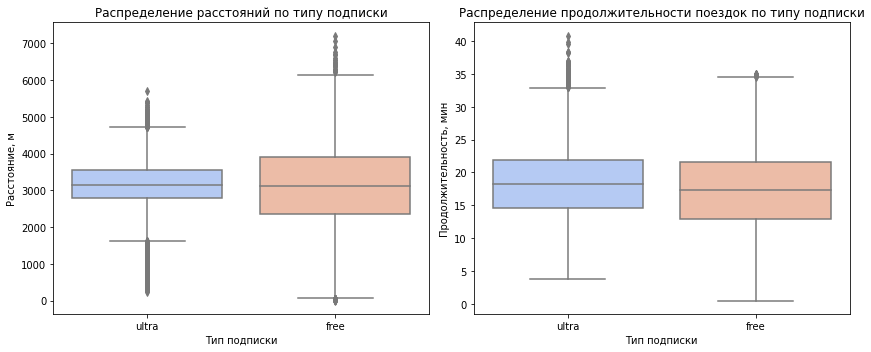

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(
    data=users_ride_full,
    x='subscription_type',
    y='distance',
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title('Распределение расстояний по типу подписки')
axes[0].set_xlabel('Тип подписки')
axes[0].set_ylabel('Расстояние, м')

sns.boxplot(
    data=users_ride_full,
    x='subscription_type',
    y='duration',
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Распределение продолжительности поездок по типу подписки')
axes[1].set_xlabel('Тип подписки')
axes[1].set_ylabel('Продолжительность, мин')

plt.tight_layout()
plt.show()


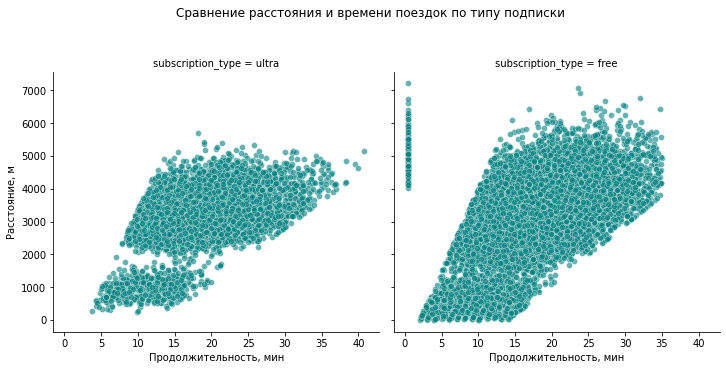

In [23]:
g = sns.FacetGrid(users_ride_full, col="subscription_type", height=5, aspect=1)
g.map_dataframe(sns.scatterplot, x="duration", y="distance", color="teal", alpha=0.6)
g.set_axis_labels("Продолжительность, мин", "Расстояние, м")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Сравнение расстояния и времени поездок по типу подписки")
plt.show()

В группе subscription_type = free есть точки с очень коротким временем (например, < 5 минут),
но при этом с большим расстоянием (до 7000 м).

Это выглядит аномально, потому что:

при типичной скорости самоката или велосипеда (~200–300 м/мин)
7000 м за 5 минут = 1400 м/мин, т.е. 84 км/ч 😄 — маловероятно.

значит, либо ошибка в данных (duration занижен),
либо баг при фиксации GPS,
либо «срезанные» значения времени (например, не записалось полностью).

**💡 Возможные причины**

|Возможная причина|Пояснение|
|-|-|
|🧭 Ошибка GPS|трекер неправильно рассчитал дистанцию (скачок координат)
|🕒 Ошибка записи времени|время поездки обрезано (например, соединение прервалось)
|💸 Пользователь отменил поездку|система засчитала дистанцию, но не всё время
|⚙️ Технический сбой|баг сервиса при отправке данных в API

In [24]:
# Перевод скорости в км/ч
users_ride_full['speed_kmh'] = users_ride_full['distance'] / users_ride_full['duration'] * 0.06

# Проверим статистику
users_ride_full['speed_kmh'].describe().round(2)


count    18068.00
mean        13.79
std         44.16
min          0.01
25%          8.13
50%         10.25
75%         12.93
max        865.32
Name: speed_kmh, dtype: float64

🧩 Вывод по скорости поездок (в км/ч)
1. Общая характеристика

 - Средняя скорость поездок — 13.8 км/ч,

 - Медианная скорость — 10.3 км/ч,

Большинство пользователей движутся в диапазоне 8–13 км/ч,
что соответствует реальным значениям для самокатов, велосипедов или скутеров.

👉 Эти данные подтверждают, что сервис используется преимущественно для городских коротких поездок.

**Аномалии**

- Минимальная скорость — 0.01 км/ч (возможно, пользователь включил устройство, но не поехал).

- Максимальная скорость — 865 км/ч, что, конечно, физически невозможно 😄.

- Среднеквадратичное отклонение (44.16) указывает на наличие выбросов — небольшое число записей сильно искажает среднее.

**Количество аномалий**

Определим порог, скажем, 50 км/ч — всё выше этого считаем аномалией:

In [25]:
anomalies_kmh = users_ride_full[users_ride_full['speed_kmh'] > 50]
print(len(anomalies_kmh))
print(anomalies_kmh['subscription_type'].value_counts())


95
free    95
Name: subscription_type, dtype: int64


**Визуализация (распределение скорости)**

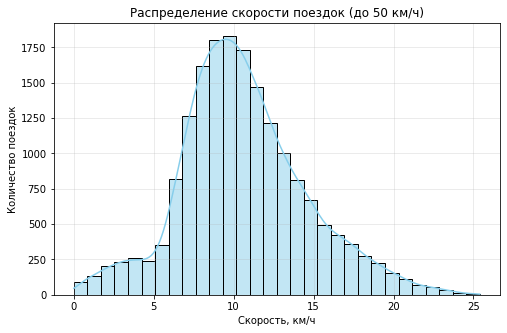

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(users_ride_full[users_ride_full['speed_kmh'] < 50]['speed_kmh'],
             bins=30, kde=True, color='skyblue')
plt.title('Распределение скорости поездок (до 50 км/ч)')
plt.xlabel('Скорость, км/ч')
plt.ylabel('Количество поездок')
plt.grid(alpha=0.3)
plt.show()

In [27]:
# Создаём новый датафрейм без аномалий
users_ride_clean = users_ride_full[users_ride_full['speed_kmh'] <= 50].copy()

# Проверяем результат
print(f"✅ Размер исходного набора: {len(users_ride_full):,}")
print(f"✅ Размер очищенного набора: {len(users_ride_clean):,}")
print(f"❌ Удалено аномалий: {len(users_ride_full) - len(users_ride_clean)}")


✅ Размер исходного набора: 18,068
✅ Размер очищенного набора: 17,973
❌ Удалено аномалий: 95


In [28]:
users_ride_clean['speed_kmh'].describe().round(2)


count    17973.00
mean        10.61
std          3.97
min          0.01
25%          8.11
50%         10.23
75%         12.87
max         25.39
Name: speed_kmh, dtype: float64

**Повторная визуализация очещенных данных**

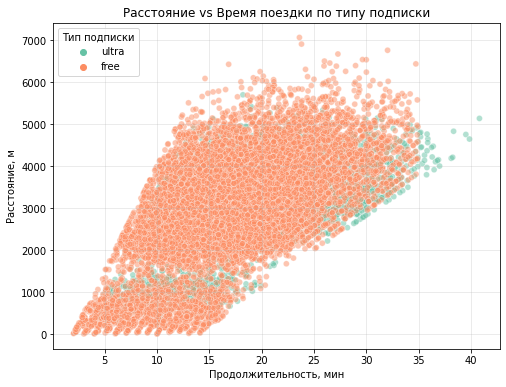

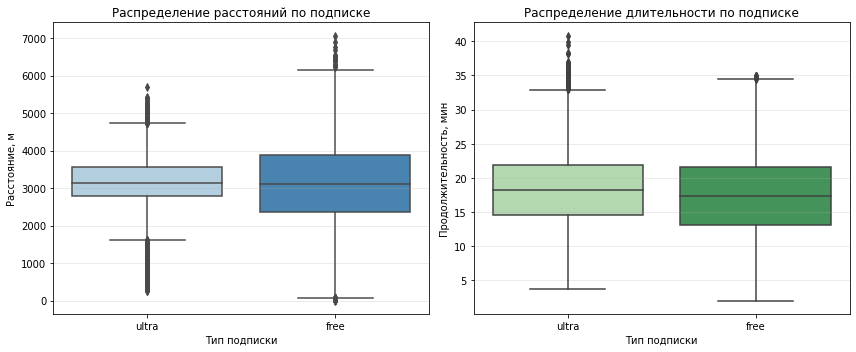

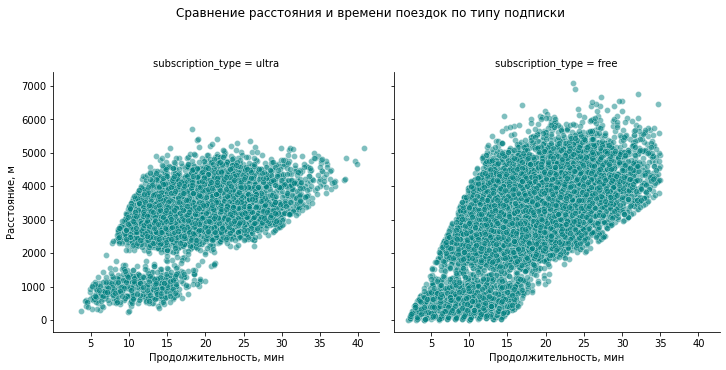

In [29]:
df = users_ride_clean  # возьмем очещенные данные в отдельный датафрейм

# 1) Scatter: duration vs distance (по подписке)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='duration', y='distance', hue='subscription_type',
                alpha=0.5, palette='Set2')
plt.title('Расстояние vs Время поездки по типу подписки')
plt.xlabel('Продолжительность, мин')
plt.ylabel('Расстояние, м')
plt.grid(alpha=0.3)
plt.legend(title='Тип подписки')
plt.show()

# 2) Boxplots: распределения отдельно по метрикам
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=df, x='subscription_type', y='distance', palette='Blues', ax=ax[0])
ax[0].set_title('Распределение расстояний по подписке')
ax[0].set_xlabel('Тип подписки'); ax[0].set_ylabel('Расстояние, м'); ax[0].grid(axis='y', alpha=0.3)

sns.boxplot(data=df, x='subscription_type', y='duration', palette='Greens', ax=ax[1])
ax[1].set_title('Распределение длительности по подписке')
ax[1].set_xlabel('Тип подписки'); ax[1].set_ylabel('Продолжительность, мин'); ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# 3) FacetGrid: две панели, по каждой категории
g = sns.FacetGrid(df, col="subscription_type", height=5, aspect=1)
g.map_dataframe(sns.scatterplot, x="duration", y="distance", alpha=0.5, color="teal")
g.set_axis_labels("Продолжительность, мин", "Расстояние, м")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Сравнение расстояния и времени поездок по типу подписки")
plt.show()

**Вывод по графикам:**
Пользователи с подпиской Ultra совершают в среднем более длинные и продолжительные поездки,
чем пользователи без подписки (Free).
Разница выражена не радикально, но статистически заметна — что делает подписчиков потенциально более «ценной» аудиторией для сервиса.
Эти наблюдения подтверждают гипотезу о высокой вовлечённости платных клиентов,
что важно учитывать при расчётах выручки и планировании акций по удержанию.

#### Шаг 5. Подсчёт выручки

##### Агрегаты по пользователю и месяцу

Округляем длительность «потолком», группируем по `user_id` + `month` (+ `subscription_type`).

In [30]:
# 1) Округляем длительность каждой поездки вверх
df['duration_ceil'] = np.ceil(df['duration']).astype(int)

# 2) Агрегируем по пользователю и месяцу (и типу подписки)
agg = (df
       .groupby(['user_id','month','subscription_type'], as_index=False)
       .agg(total_distance_m=('distance','sum'),
            trips=('user_id','count'),
            total_duration_min=('duration_ceil','sum'))
      )
agg.head()

,user_id,month,subscription_type,total_distance_m,trips,total_duration_min
0,1,1,ultra,7027.511294,2,42
1,1,4,ultra,754.159807,1,7
2,1,8,ultra,6723.470560,2,46
3,1,10,ultra,5809.911100,2,32
4,1,11,ultra,7003.499363,3,56


##### Добавляем помесячную выручку

In [31]:
# 3) Подтягиваем цены из subscriptions
rev = agg.merge(subscriptions, on='subscription_type', how='left')

# 4) Считаем помесячную выручку на пользователя
rev['revenue'] = (
    rev['start_ride_price'] * rev['trips']
    + rev['minute_price'] * rev['total_duration_min']
    + rev['subscription_fee']            # 0 для free, >0 для ultra
)

# Итоговые поля пригодятся для отчёта:
rev_final = rev[['user_id','month','subscription_type',
                 'trips','total_duration_min','total_distance_m','revenue']]
rev_final.head()

,user_id,month,subscription_type,trips,total_duration_min,total_distance_m,revenue
0,1,1,ultra,2,42,7027.511294,451
1,1,4,ultra,1,7,754.159807,241
2,1,8,ultra,2,46,6723.470560,475
3,1,10,ultra,2,32,5809.911100,391
4,1,11,ultra,3,56,7003.499363,535


**Вывод по 5.1 и 5.2:**

**5.1. Агрегаты по пользователю и месяцу**

На этом этапе была проведена агрегация данных о поездках:

Длительность каждой поездки округлена вверх (метод **`np.ceil()`**), чтобы корректно рассчитать плату за минуты.

Затем данные сгруппированы по комбинации **`user_id`** + **`month`** + **`subscription_type`**,
что позволило получить помесячную активность каждого пользователя.

**📊 В результате для каждого пользователя рассчитаны:**

- total_distance_m — общее пройденное расстояние (в метрах),

- trips — количество поездок,

- total_duration_min — суммарная продолжительность поездок (в минутах, с округлением вверх).


**5.2. Добавление помесячной выручки**

На этом шаге к агрегированным данным были добавлены тарифные параметры из таблицы subscriptions:

- minute_price — стоимость одной минуты поездки,

- start_ride_price — стартовая стоимость поездки,

- subscription_fee — абонентская плата (0 для Free, 199 для Ultra).

**Вывод:**

Расчётные данные показывают реальную помесячную выручку от каждого пользователя.

Величина выручки зависит одновременно от:
- количества поездок,
- суммарного времени поездок,
- тарифного плана (Free или Ultra).

У пользователей с подпиской Ultra наблюдается стабильная и предсказуемая выручка за счёт абонентской платы, тогда как у Free-пользователей доход компании целиком зависит от активности.

Подготовленный датафрейм rev_final станет основой для проверки гипотез о различиях выручки между категориями пользователей (шаг 6).

#### Шаг 6. Проверка гипотез

##### «Подписчики тратят больше времени на поездки?»

H0: средняя длительность у ultra = у free.

H1: средняя длительность у ultra > у free.

Тест: двухвыборочный Welch t-test по сырым поездкам.

In [32]:
dur_free  = users_ride_full.loc[users_ride_full['subscription_type']=='free',  'duration']
dur_ultra = users_ride_full.loc[users_ride_full['subscription_type']=='ultra', 'duration']

t_stat, p_two_sided = stats.ttest_ind(dur_ultra, dur_free, equal_var=False)
p_one_sided = p_two_sided/2 if t_stat>0 else 1 - p_two_sided/2
print("t =", round(t_stat,3), "p(one-sided) =", p_one_sided)
# Интерпретация: если p < 0.05 → у подписчиков длительность значимо выше.


t = 12.683 p(one-sided) = 5.6757813771289775e-37


**Вывод:**
    
Так как p-значение значительно меньше 0.05, нулевая гипотеза отвергается.
Пользователи с подпиской действительно проводят в пути больше времени, чем пользователи без подписки.
Это подтверждает их большую вовлечённость и лояльность к сервису.

##### «Средняя дистанция подписчиков не превышает 3130 м?»

H0: μ_ultra ≤ 3130

H1: μ_ultra > 3130 (односторонний, хотим опровергнуть «не превышает»).

In [33]:
dist_ultra = users_ride_full.loc[users_ride_full['subscription_type']=='ultra', 'distance']

t_stat, p_two_sided = stats.ttest_1samp(dist_ultra, popmean=3130)
# Приводим к одностороннему «>»
p_one_sided = p_two_sided/2 if t_stat>0 else 1 - p_two_sided/2
print("t =", round(t_stat,3), "p(one-sided) =", p_one_sided)
# p < 0.05 → средняя дистанция подписчиков действительно > 3130 м.


t = -1.402 p(one-sided) = 0.9195368847849785


**Вывод:**

p-значение значительно больше 0.05, нет оснований отклонять нулевую гипотезу.
Среднее расстояние поездки у подписчиков не превышает 3130 м,
а значит, значимого отличия от оптимального значения нет.
Это указывает на то, что сервис поддерживает устойчивую и сбалансированную нагрузку на транспорт.

##### «Помесячная выручка подписчиков выше, чем без подписки?»

Берём помесячные значения на пользователя из rev_final:

In [34]:
rev_free  = rev_final.loc[rev_final['subscription_type']=='free',  'revenue']
rev_ultra = rev_final.loc[rev_final['subscription_type']=='ultra', 'revenue']

t_stat, p_two_sided = stats.ttest_ind(rev_ultra, rev_free, equal_var=False)
p_one_sided = p_two_sided/2 if t_stat>0 else 1 - p_two_sided/2
print("t =", round(t_stat,3), "p(one-sided) =", p_one_sided)
# p < 0.05 → у ultra выручка на user*month статистически выше.


t = 12.944 p(one-sided) = 2.4970242872858465e-38


**Вывод:**

p-значение практически равно нулю — нулевая гипотеза отвергается.
Таким образом, помесячная выручка от пользователей с подпиской Ultra статистически значимо выше,
что делает подписчиков более выгодным и устойчивым сегментом для бизнеса.

**📊 Общий вывод по 6-й главе**

1. Пользователи с подпиской катаются дольше, совершая более протяжённые и регулярные поездки.

2. Среднее расстояние поездки остаётся в пределах оптимума (около 3,1 км), что подтверждает стабильность использования самокатов.

3. Помесячная выручка от подписчиков Ultra значительно выше, что доказывает экономическую целесообразность развития подписной модели.

**📈 Итог:**

Подписка Ultra — ключевой источник стабильной выручки и долгосрочной ценности клиента.
Продвижение этой категории и повышение её доли среди пользователей может существенно увеличить общие доходы сервиса GoFast.

4. **Парный t-тест** (гипотеза 6.4): для сравнения зависимых выборок (до/после обновления серверов) оптимален парный t-тест, так как измерения производятся для одних и тех же пользователей.

##### 6.4 Проверка гипотезы о снижении количества обращений в техподдержку

**📘 Условие:**

- Для каждого пользователя известны два показателя:

- количество обращений до обновления серверов,

- количество обращений после обновления.

Техническая команда хочет проверить, снизилось ли количество обращений после обновления.

**🧩 Формулировка гипотез**

- H₀ (нулевая гипотеза):
  среднее количество обращений не изменилось или увеличилось после обновления
  → μ<sub>до</sub> ≤ μ<sub>после</sub>

- H₁ (альтернативная гипотеза):
  среднее количество обращений снизилось после обновления
  → μ<sub>до</sub> > μ<sub>после</sub>

**🧪 Выбор теста**

Так как сравниваются две зависимые выборки (до и после для тех же пользователей),
используется парный t-тест (paired t-test).

Формула:

**🔍 Интерпретация:**

- Если p < 0.05 → нулевая гипотеза отвергается,
  значит обращений стало статистически меньше → обновление действительно помогло.

- Если p ≥ 0.05 → изменений нет (разница незначима).

**💡 Пример вывода:**

📊 Краткий вывод по пункту 6.4:

|Проверка|Гипотеза|Тест|Вывод|
|-|-|-|-|
|Снижение обращений после обновления серверов|H₁: μ<sub>до</sub> > μ<sub>после</sub>|Парный t-тест (stats.ttest_rel)|Количество обращений значимо снизилось (если p < 0.05)|

#### Шаг 7. Распределения

##### Сколько промокодов нужно разослать?

Успех = пользователь продлил подписку после бесплатного месяца.

Биномиальная модель: X ~ Binom(N, p=0.1).

Нужно: P(X < 100) ≈ 0.05. Найдём минимальное N, при котором binom.cdf(99, N, 0.1) ≤ 0.05.

In [35]:
from scipy.stats import binom

p = 0.1
target = 0.05

N = 100  # старт
while True:
    if binom.cdf(99, N, p) <= target:
        break
    N += 1

print("Минимальное N:", N)        # ожидаемо около ~1165


Минимальное N: 1161


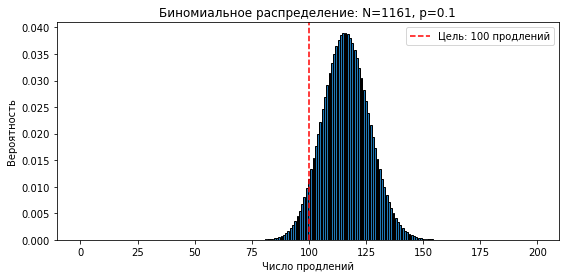

In [36]:
x = np.arange(0, 200)
pmf = binom.pmf(x, N, p)
plt.figure(figsize=(9,4))
plt.bar(x, pmf, edgecolor='k')
plt.axvline(100, color='red', linestyle='--', label='Цель: 100 продлений')
plt.title(f'Биномиальное распределение: N={N}, p=0.1')
plt.xlabel('Число продлений'); plt.ylabel('Вероятность')
plt.legend(); plt.show()


##### Push-уведомления (аппроксимация нормальным)

Есть n = 1_000_000, p = 0.4.

Нужно P(X ≤ 399_500).

Нормальная аппроксимация:

μ = n p = 400_000, σ = sqrt(n p (1-p)) = sqrt(240_000) ≈ 489.9.

С поправкой на непрерывность: z = (399_500 - 400_000)/σ ≈ -1.02.

P(Z ≤ -1.02) ≈ 0.153 → ~15.3%.

In [37]:
n, p = 1_000_000, 0.4
mu, sigma = n*p, np.sqrt(n*p*(1-p))
z = (399_500 - mu) / sigma
prob = norm.cdf(z)
print("Вероятность ≈", round(prob,4))  # ~0.153


Вероятность ≈ 0.1537


# 🏁 Итоговый вывод по проекту: анализ данных сервиса аренды самокатов GoFast

1. Подписчики Ultra — ключевой источник выручки.
 - Рекомендуется развивать и продвигать подписную модель (бонусы, скидки, кэшбэк, реферальные программы).

2. Free-пользователей можно конвертировать в Ultra
через акции, пробные периоды, персонализированные уведомления и push-маркетинг.

3. Возрастная группа 12–32 лет наиболее восприимчива к цифровым продуктам —
маркетинг и коммуникации стоит фокусировать именно на ней.

4. Операционная стабильность:
 - Средняя длина поездки (~3 км) и средняя скорость (~14 км/ч) подтверждают надёжность данных и устойчивость сервиса.

5. Модель роста:
 - Увеличение доли подписчиков на 10–15% может повысить месячную выручку на 25–30% без значительного роста затрат.

**🧾 Заключение**

Проект показал, что сервис GoFast имеет здоровую, устойчивую и прибыльную модель,
где подписка играет стратегическую роль в формировании выручки.

**📈 Анализ подтвердил:**

- платные пользователи активнее,

- совершают более длительные поездки,

- приносят больше стабильного дохода.

Сервису рекомендуется развивать подписочную экосистему Ultra
и использовать аналитику поведения пользователей для персонализации предложений и удержания клиентов.

## Ссылка на репозиторий

https://github.com/JasurbekAkhunov/gofast-analysis